# SVAMITVA Segmentation  Visualization Notebook
Shows: **Satellite Image | Ground Truth | Prediction** side by side

In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
from pathlib import Path
import segmentation_models_pytorch as smp

print('Libraries loaded ✅')

c:\Users\24bcscs005\Downloads\PB_training_dataSet_shp_file\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded ✅


In [3]:
# ── Cell 2: CONFIG — edit these paths ────────────────────────

IMG_DIR         = 'dataset/images'       # folder with image_*.npy files
MASK_DIR        = 'dataset/masks'        # folder with mask_*.npy files
CHECKPOINT_PATH = 'deeplab_best_v4.pth'  # your saved model

NUM_CLASSES  = 5
CLASS_NAMES  = ['Background', 'BuiltUp', 'Road', 'WaterBody', 'Farm']

# Color for each class in visualization
# Matches QGIS GT colors: bg=black, builtup=pink, road=green, water=lightpink, farm=yellow
CLASS_COLORS = np.array([
    [0,   0,   0  ],   # 0 Background  → black
    [255, 105, 180],   # 1 Built-up    → pink
    [0,   200, 0  ],   # 2 Road        → green
    [135, 206, 250],   # 3 Water Body  → sky blue
    [255, 215, 0  ],   # 4 Farm        → yellow
], dtype=np.uint8)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [4]:
# ── Cell 3: Load Model from Checkpoint ───────────────────────

ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')

MEAN = ckpt['mean']   # dataset mean saved during training
STD  = ckpt['std']    # dataset std  saved during training

model = smp.DeepLabV3Plus(
    encoder_name    = 'resnet50',
    encoder_weights = None,       # no re-download, we load our weights
    in_channels     = 5,          # RGB + NDVI + NDWI
    classes         = NUM_CLASSES,
    activation      = None,
)
model.load_state_dict(ckpt['model_state'])
model.to(DEVICE)
model.eval()

print(f"Model loaded ✅  (best epoch={ckpt['epoch']}, mIoU={ckpt['best_miou']:.4f})")

C:\Users\24bcscs005\AppData\Local\Temp\ipykernel_7416\3983879288.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')


Model loaded ✅  (best epoch=80, mIoU=0.6960)


In [11]:
# ── Cell 4: Helper Functions ──────────────────────────────────

def add_spectral_indices(img_hwc):
    """Add NDVI + NDWI channels to RGB image. Returns (H,W,5)."""
    R = img_hwc[:,:,0].astype(np.float32)
    G = img_hwc[:,:,1].astype(np.float32)
    B = img_hwc[:,:,2].astype(np.float32)
    ndvi = (G - R) / (G + R + 1e-6)
    ndwi = (G - B) / (G + B + 1e-6)
    return np.concatenate([img_hwc,
                           ndvi[:,:,None],
                           ndwi[:,:,None]], axis=-1)


# ── Cell 4: Helper Functions ──────────────────────────────────

def add_spectral_indices(img_hwc):
    """Add NDVI + NDWI channels to RGB image. Returns (H,W,5)."""
    R = img_hwc[:,:,0].astype(np.float32)
    G = img_hwc[:,:,1].astype(np.float32)
    B = img_hwc[:,:,2].astype(np.float32)
    ndvi = (G - R) / (G + R + 1e-6)
    ndwi = (G - B) / (G + B + 1e-6)
    return np.concatenate([img_hwc,
                           ndvi[:,:,None],
                           ndwi[:,:,None]], axis=-1)


def load_and_preprocess(img_path, mask_path):
    img  = np.load(img_path).astype(np.float32)
    mask = np.load(mask_path).astype(np.int64)

    if img.shape[0] == 3:           # CHW → HWC
        img = img.transpose(1, 2, 0)

    # ── FIX: build display image from RAW pixel values ──
    # Your .npy might be 0-1 float OR 0-255 — handle both
    raw = img.copy()
    if raw.max() <= 1.0:
        # Values are 0-1 float → scale to 0-255
        img_display = (raw * 255).clip(0, 255).astype(np.uint8)
    else:
        # Values are already 0-255
        img_display = raw.clip(0, 255).astype(np.uint8)

    # ── Spectral indices on raw values (before normalization) ──
    img_spec = add_spectral_indices(raw)              # (H,W,5)

    # ── Normalize only RGB channels ──
    img_norm = img_spec.copy()
    img_norm[:,:,:3] = (img_spec[:,:,:3] - MEAN[:3]) / (STD[:3] + 1e-6)

    img_tensor = torch.tensor(
        img_norm.transpose(2,0,1), dtype=torch.float32
    ).unsqueeze(0)                                    # (1,5,H,W)

    return img_tensor, img_display, mask


@torch.no_grad()
def predict(img_tensor):
    """Run TTA (4 flips) and return (H,W) argmax prediction."""
    imgs = img_tensor.to(DEVICE)
    p  = torch.softmax(model(imgs), dim=1)
    p += torch.flip(torch.softmax(model(torch.flip(imgs,[3])),dim=1),[3])
    p += torch.flip(torch.softmax(model(torch.flip(imgs,[2])),dim=1),[2])
    p += torch.flip(torch.softmax(model(torch.flip(imgs,[2,3])),dim=1),[2,3])
    p /= 4.0
    return p.argmax(dim=1).squeeze(0).cpu().numpy()


def mask_to_rgb(mask):
    mask = np.clip(mask, 0, NUM_CLASSES-1)
    return CLASS_COLORS[mask]


def compute_iou(pred, gt, num_classes=NUM_CLASSES):
    result = {}
    for c in range(num_classes):
        pc = (pred == c); gc = (gt == c)
        inter = (pc & gc).sum(); union = (pc | gc).sum()
        result[CLASS_NAMES[c]] = inter/union if union > 0 else float('nan')
    return result


# Build file list
img_files = sorted(Path(IMG_DIR).glob('*.npy'))
print(f'Found {len(img_files)} images ✅')


@torch.no_grad()
def predict(img_tensor):
    """Run TTA (4 flips) and return (H,W) argmax prediction."""
    imgs = img_tensor.to(DEVICE)

    p  = torch.softmax(model(imgs), dim=1)
    p += torch.flip(torch.softmax(model(torch.flip(imgs,[3])),dim=1),[3])
    p += torch.flip(torch.softmax(model(torch.flip(imgs,[2])),dim=1),[2])
    p += torch.flip(torch.softmax(model(torch.flip(imgs,[2,3])),dim=1),[2,3])
    p /= 4.0

    return p.argmax(dim=1).squeeze(0).cpu().numpy()


def mask_to_rgb(mask):
    """Convert (H,W) class index mask → (H,W,3) RGB image."""
    mask  = np.clip(mask, 0, NUM_CLASSES-1)
    return CLASS_COLORS[mask]


def compute_iou(pred, gt, num_classes=NUM_CLASSES):
    """Return per-class IoU dict."""
    result = {}
    for c in range(num_classes):
        pc = (pred == c)
        gc = (gt   == c)
        inter = (pc & gc).sum()
        union = (pc | gc).sum()
        result[CLASS_NAMES[c]] = inter/union if union > 0 else float('nan')
    return result


# Build file list
img_files = sorted(Path(IMG_DIR).glob('*.npy'))
print(f'Found {len(img_files)} images ✅')

Found 12291 images ✅
Found 12291 images ✅


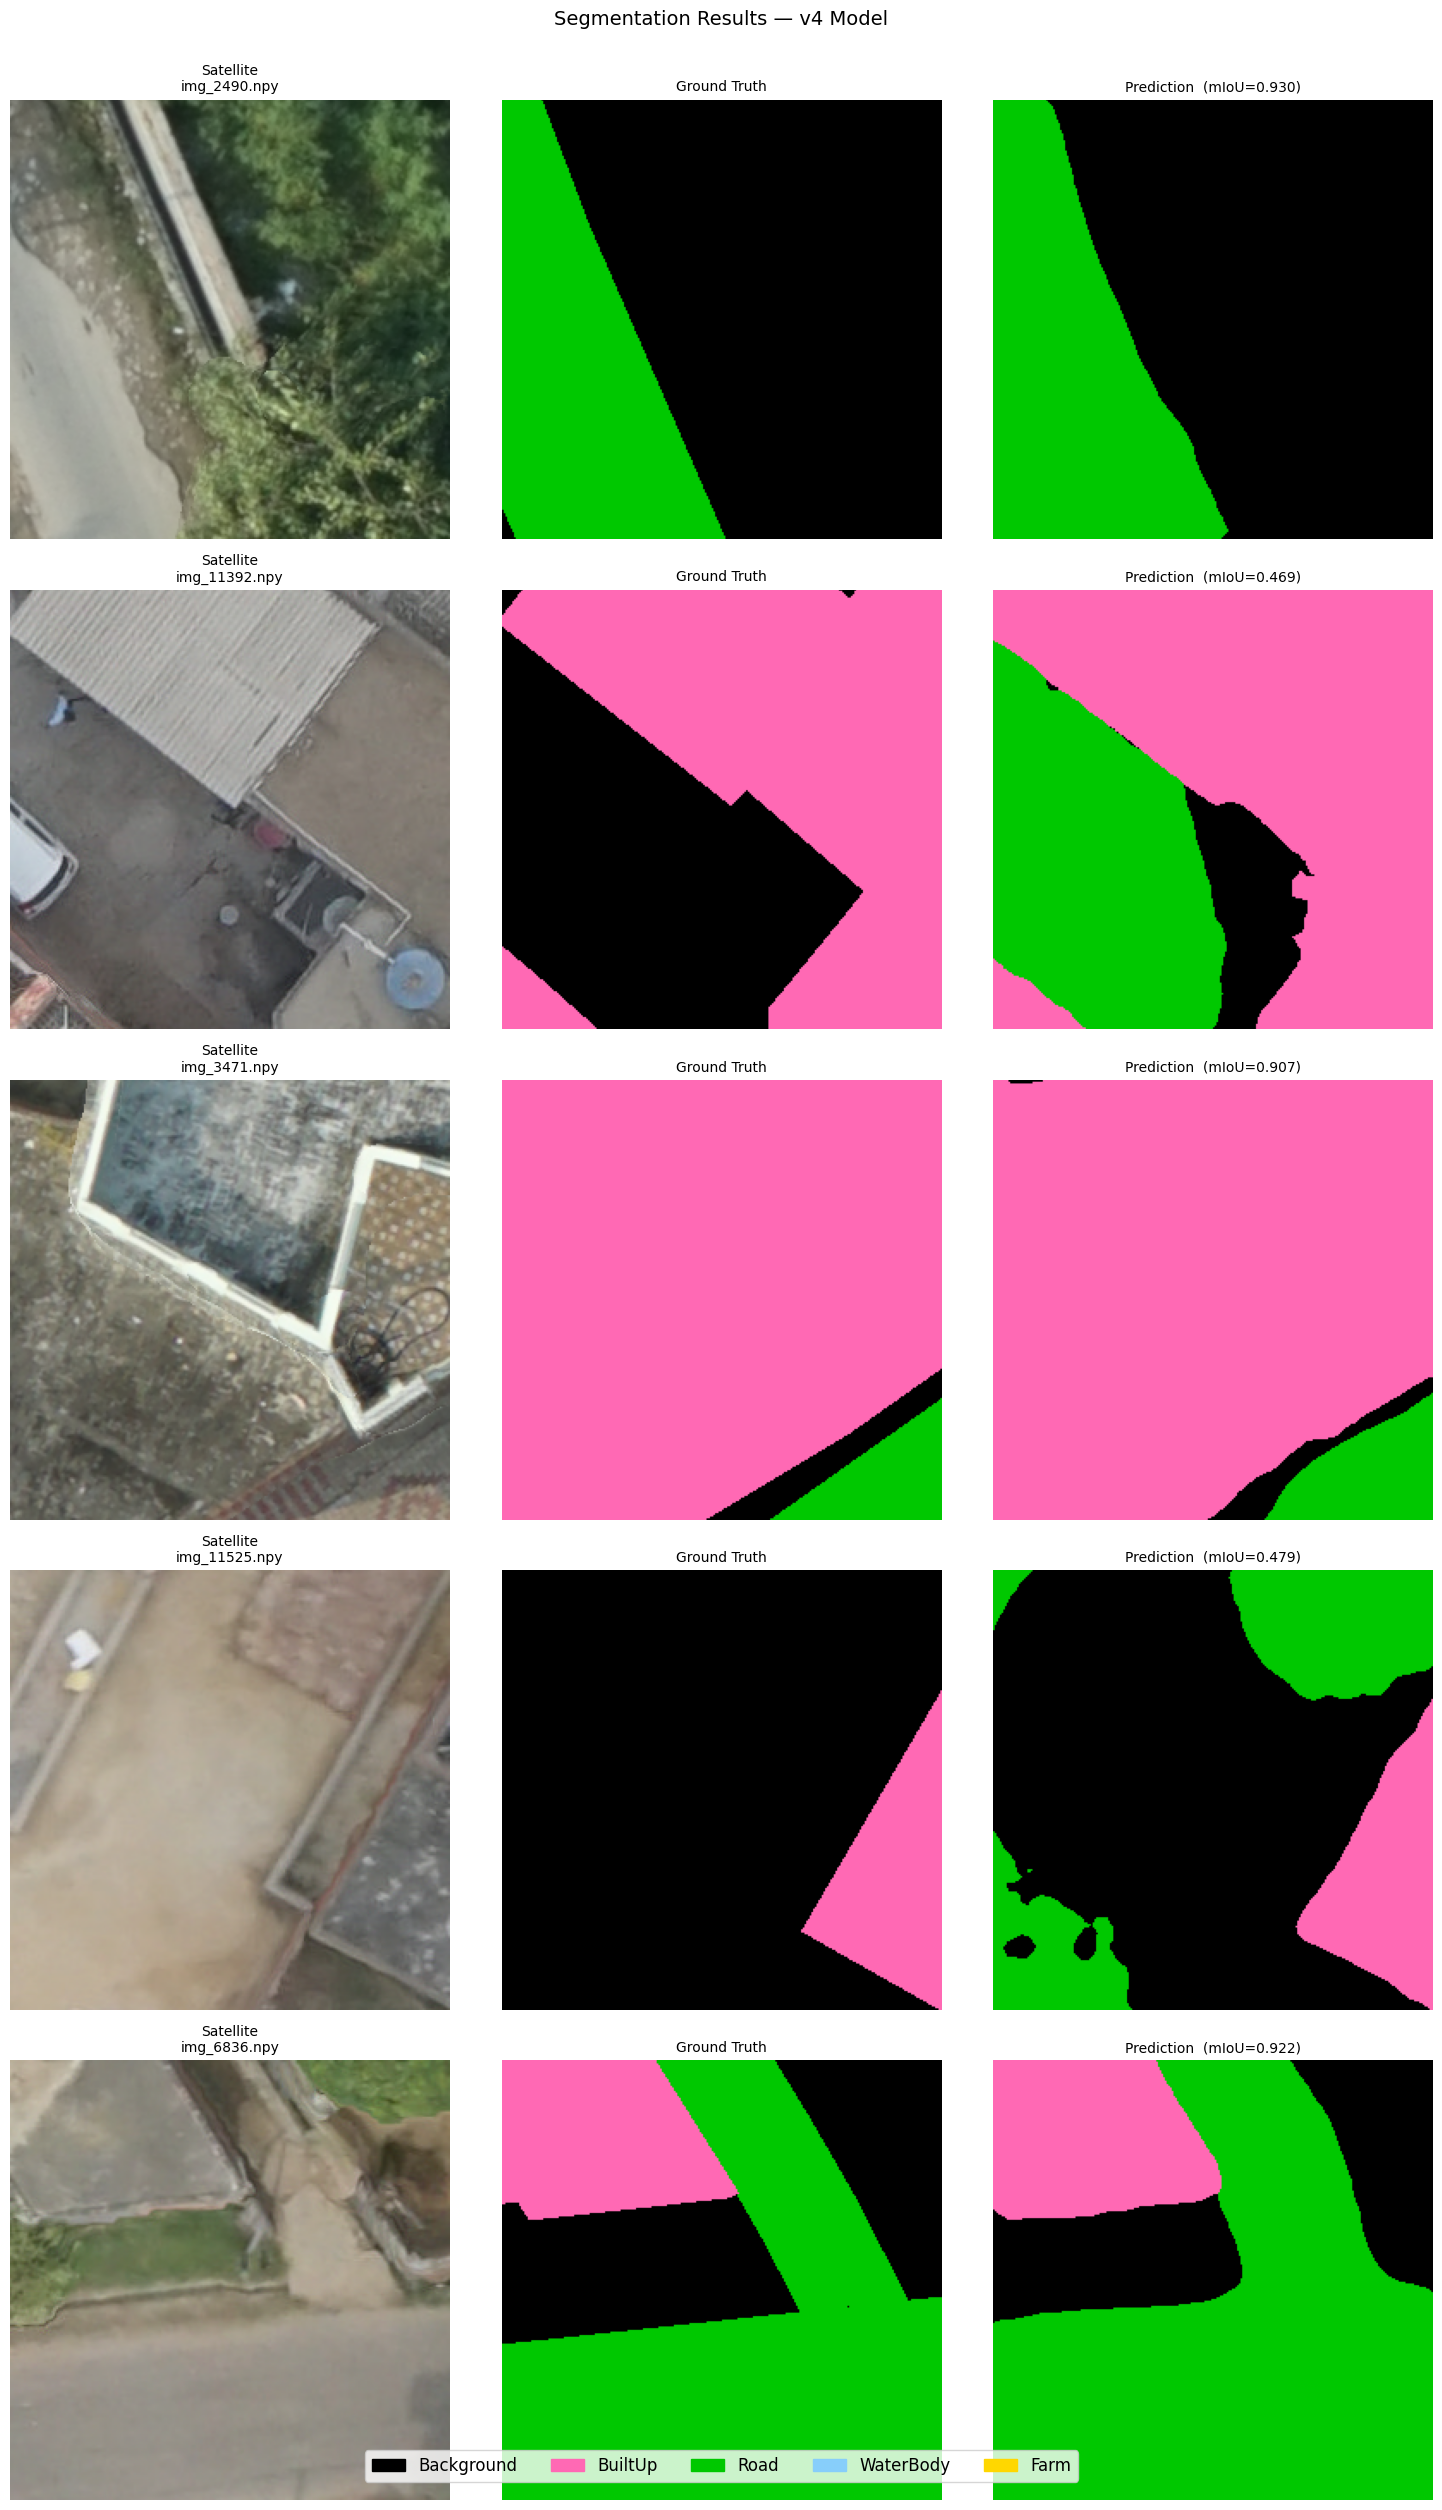

Saved: vis_random_samples.png


In [15]:
# ── Cell 5: Visualize N Random Samples ───────────────────────
# Change NUM_SHOW to see more/fewer samples

NUM_SHOW = 5   # ← change this

# Build valid pairs
pairs = []
for ip in img_files:
    idx = ip.stem.split('_')[1]
    mp  = Path(MASK_DIR) / f'mask_{idx}.npy'
    if mp.exists():
        pairs.append((ip, mp))

samples = random.sample(pairs, min(NUM_SHOW, len(pairs)))

fig, axes = plt.subplots(NUM_SHOW, 3, figsize=(15, 5 * NUM_SHOW))
if NUM_SHOW == 1:
    axes = [axes]

for row, (img_path, mask_path) in enumerate(samples):
    img_tensor, img_display, gt_mask = load_and_preprocess(img_path, mask_path)
    pred_mask = predict(img_tensor)

    gt_rgb   = mask_to_rgb(gt_mask)
    pred_rgb = mask_to_rgb(pred_mask)

    # Per-sample IoU
    ious = compute_iou(pred_mask, gt_mask)
    miou = np.nanmean([v for k,v in ious.items() if k != 'Background'])

    axes[row][0].imshow(img_display)
    axes[row][0].set_title(f'Satellite\n{img_path.name}', fontsize=10)

    axes[row][1].imshow(gt_rgb)
    axes[row][1].set_title('Ground Truth', fontsize=10)

    axes[row][2].imshow(pred_rgb)
    axes[row][2].set_title(f'Prediction  (mIoU={miou:.3f})', fontsize=10)

    for ax in axes[row]:
        ax.axis('off')

# Legend
patches = [mpatches.Patch(color=CLASS_COLORS[c]/255, label=CLASS_NAMES[c])
           for c in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=NUM_CLASSES,
           fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.01))

plt.suptitle('Segmentation Results — v4 Model', fontsize=14, y=1.002)
plt.tight_layout()
plt.savefig('vis_random_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: vis_random_samples.png')

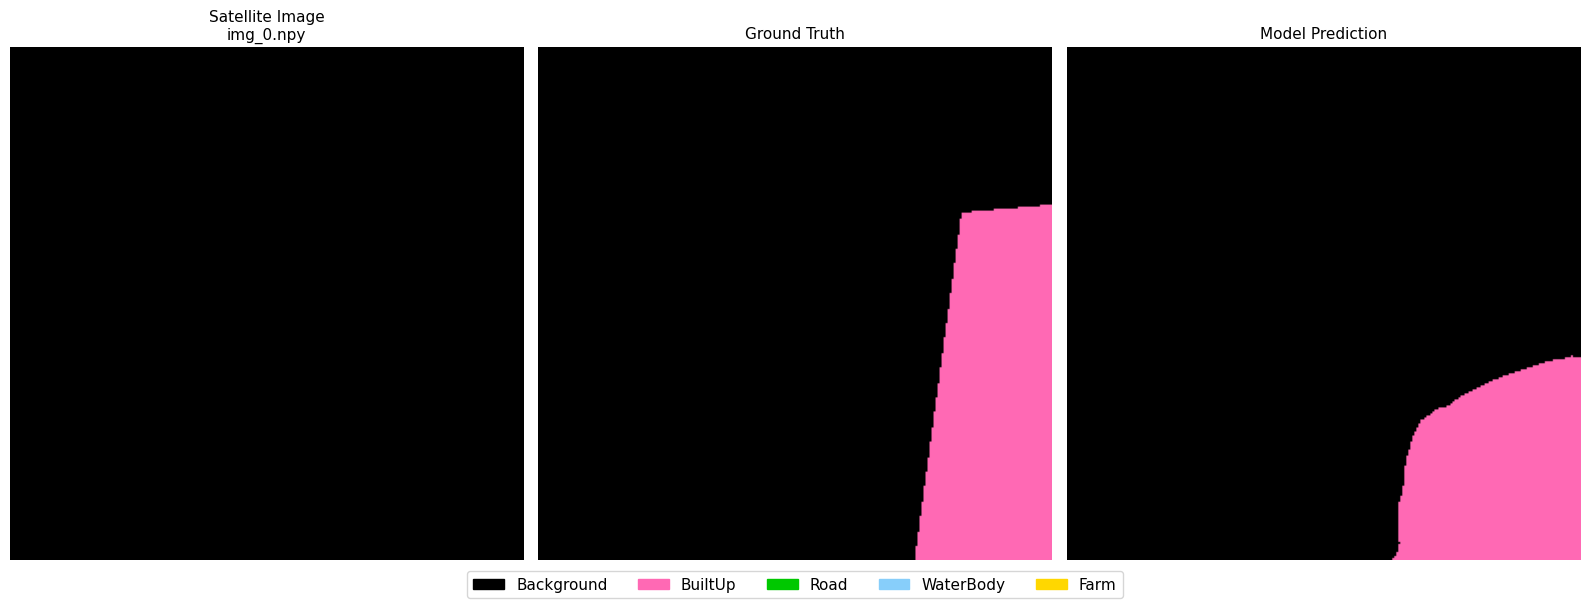

In [7]:
# ── Cell 6: Visualize a SPECIFIC image by index or filename ──
# Set IMAGE_IDX to any number, or set IMAGE_NAME to a filename

IMAGE_IDX  = 0           # ← change: 0,1,2,3 ... index in the list
# IMAGE_NAME = 'image_42.npy'  # ← OR use exact filename

img_path, mask_path = pairs[IMAGE_IDX]
img_tensor, img_display, gt_mask = load_and_preprocess(img_path, mask_path)
pred_mask = predict(img_tensor)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(img_display)
axes[0].set_title(f'Satellite Image\n{img_path.name}', fontsize=11)

axes[1].imshow(mask_to_rgb(gt_mask))
axes[1].set_title('Ground Truth', fontsize=11)

axes[2].imshow(mask_to_rgb(pred_mask))
axes[2].set_title('Model Prediction', fontsize=11)

for ax in axes: ax.axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[c]/255, label=CLASS_NAMES[c])
           for c in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=NUM_CLASSES, fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# ── Cell 7: Per-class IoU Table for all val samples ──────────

all_ious = {name: [] for name in CLASS_NAMES}

for img_path, mask_path in pairs:
    img_tensor, _, gt_mask = load_and_preprocess(img_path, mask_path)
    pred_mask = predict(img_tensor)
    ious      = compute_iou(pred_mask, gt_mask)
    for cls, iou in ious.items():
        if not np.isnan(iou):
            all_ious[cls].append(iou)

print('\n========== Per-Class IoU (all samples) ==========')
miou_vals = []
for cls in CLASS_NAMES:
    mean_iou = np.mean(all_ious[cls]) if all_ious[cls] else float('nan')
    bar = '█' * int(mean_iou * 30)
    print(f'  {cls:12s}: {mean_iou:.4f}  {bar}')
    if cls != 'Background':
        miou_vals.append(mean_iou)
print(f'  {"─"*40}')
print(f'  mIoU (no bg): {np.nanmean(miou_vals):.4f}')
print('==================================================')


========== Per-Class IoU (all samples) ==========
  Background  : 0.6057  ██████████████████
  BuiltUp     : 0.8287  ████████████████████████
  Road        : 0.3346  ██████████
  WaterBody   : 0.7571  ██████████████████████


ValueError: cannot convert float NaN to integer

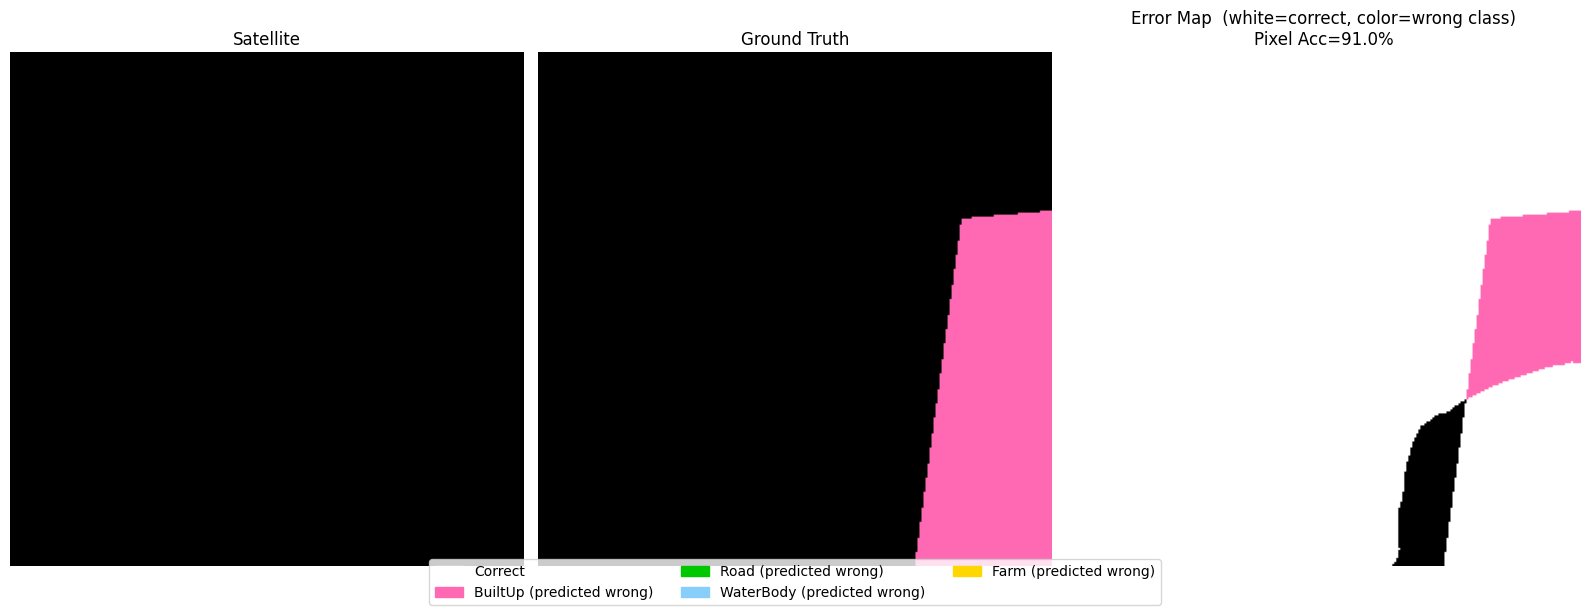

Saved: error_map.png


In [9]:
# ── Cell 8: Error Map — where exactly is the model wrong? ────
# Shows which pixels are correct (white) vs wrong (colored by true class)

IMAGE_IDX = 0   # ← change to any sample

img_path, mask_path = pairs[IMAGE_IDX]
img_tensor, img_display, gt_mask = load_and_preprocess(img_path, mask_path)
pred_mask = predict(img_tensor)

correct    = (pred_mask == gt_mask)
error_mask = gt_mask.copy()
error_mask[correct] = 0              # correct pixels → background (black)

error_rgb = mask_to_rgb(error_mask)
# Make correct pixels white instead of black
error_rgb[correct] = [255, 255, 255]

acc = correct.mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(img_display);          axes[0].set_title('Satellite')
axes[1].imshow(mask_to_rgb(gt_mask)); axes[1].set_title('Ground Truth')
axes[2].imshow(error_rgb)
axes[2].set_title(f'Error Map  (white=correct, color=wrong class)\nPixel Acc={acc:.1f}%')

for ax in axes: ax.axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[c]/255,
                           label=f'{CLASS_NAMES[c]} (predicted wrong)')
           for c in range(1, NUM_CLASSES)]
patches.insert(0, mpatches.Patch(color=[1,1,1], label='Correct'))
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10)
plt.tight_layout()
plt.savefig('error_map.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: error_map.png')

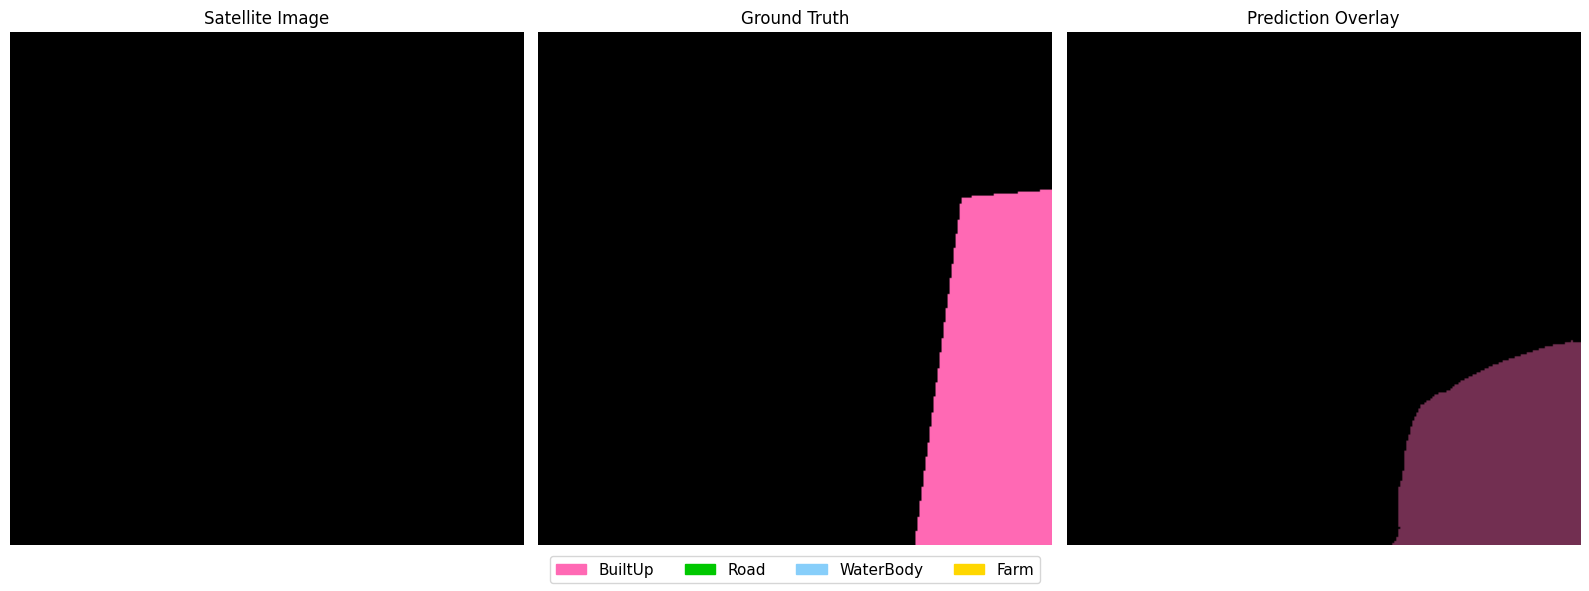

Saved: overlay.png


In [10]:
# ── Cell 9: Overlay prediction on satellite (transparency) ───
# Helps see prediction on top of actual image

IMAGE_IDX = 0   # ← change
ALPHA     = 0.45  # transparency: 0=invisible, 1=opaque

img_path, mask_path = pairs[IMAGE_IDX]
img_tensor, img_display, gt_mask = load_and_preprocess(img_path, mask_path)
pred_mask = predict(img_tensor)

pred_rgb   = mask_to_rgb(pred_mask).astype(np.float32)
img_float  = img_display.astype(np.float32)

# Blend: only color non-background predictions
overlay = img_float.copy()
fg_mask = (pred_mask != 0)
overlay[fg_mask] = (
    (1 - ALPHA) * img_float[fg_mask] + ALPHA * pred_rgb[fg_mask]
)
overlay = overlay.clip(0, 255).astype(np.uint8)

gt_rgb = mask_to_rgb(gt_mask)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(img_display);  axes[0].set_title('Satellite Image')
axes[1].imshow(gt_rgb);       axes[1].set_title('Ground Truth')
axes[2].imshow(overlay);      axes[2].set_title('Prediction Overlay')

for ax in axes: ax.axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[c]/255, label=CLASS_NAMES[c])
           for c in range(1, NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=NUM_CLASSES-1, fontsize=11)
plt.tight_layout()
plt.savefig('overlay.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: overlay.png')